In [ ]:
!pip install opencv-python
!pip install matplotlib

In [7]:
import os
import cv2
import matplotlib.pyplot as plt

In [11]:
#import os
#print(os.getcwd()) # check current location
image_dir = "../public/datasets/Kvasir-seg/images"
mask_dir = "../public/datasets/Kvasir-seg/masks"

In [12]:
image_files = os.listdir(image_dir)

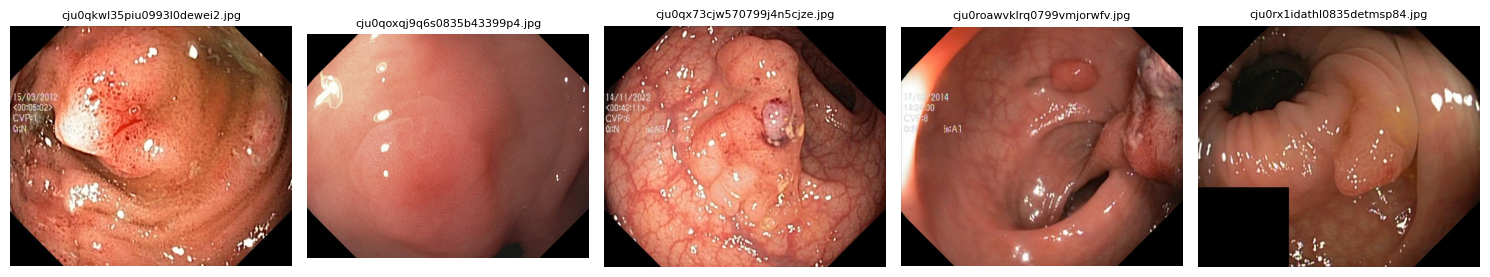

In [19]:

sample_images = image_files[:5]
fig, axes = plt.subplots(1, 5, figsize=(15,5))
for i, img_name in enumerate(sample_images):
    img_path = os.path.join(image_dir, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(img_name, fontsize=8)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

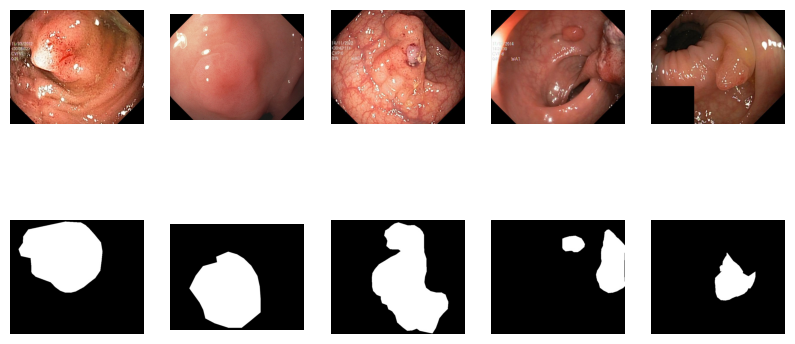

In [15]:
plt.figure(figsize=(10,5))

for i, img_name in enumerate(sample_images):
    img_path = os.path.join(image_dir, img_name)
    mask_path = os.path.join(mask_dir, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, 0)
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.subplot(2, 5, i+6)
    plt.imshow(mask, cmap='gray')
    plt.axis('off')

plt.show()

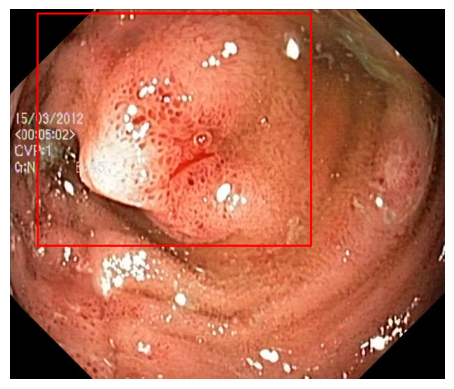

In [18]:
def get_bbox(mask):
    _, thresh = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        boxes.append((x, y, w, h))
    return boxes
img_name = sample_images[0]
img_path = os.path.join(image_dir, img_name)
mask_path = os.path.join(mask_dir, img_name)
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_path, 0)
boxes = get_bbox(mask)
# bbox draw
for (x, y, w, h) in boxes:
    cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)
plt.imshow(img)
plt.axis('off')
plt.show()